In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("data/raw/cs-training.csv",index_col=0)
df.head()
df.shape

(150000, 11)

In [2]:

print(df['SeriousDlqin2yrs'].value_counts())
print("\nClass balance %: ")
print(df['SeriousDlqin2yrs'].value_counts(normalize=True)*100)

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Class balance %: 
SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


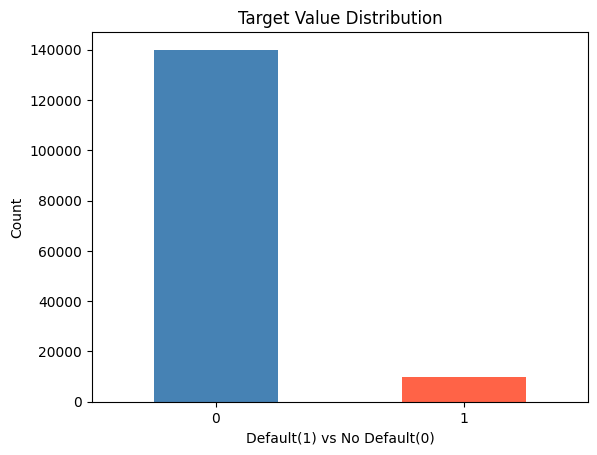

In [3]:
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar',color=['steelblue','tomato'])
plt.title('Target Value Distribution')
plt.xlabel('Default(1) vs No Default(0)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [4]:
missing=df.isnull().sum()
missing_pct=(df.isnull().sum()/len(df))*100

missing_df=pd.DataFrame({
    'Missing Count' : missing,
    'Missing %':missing_pct
}).sort_values('Missing %',ascending=False)

print(missing_df[missing_df['Missing Count']>0])

                    Missing Count  Missing %
MonthlyIncome               29731  19.820667
NumberOfDependents           3924   2.616000


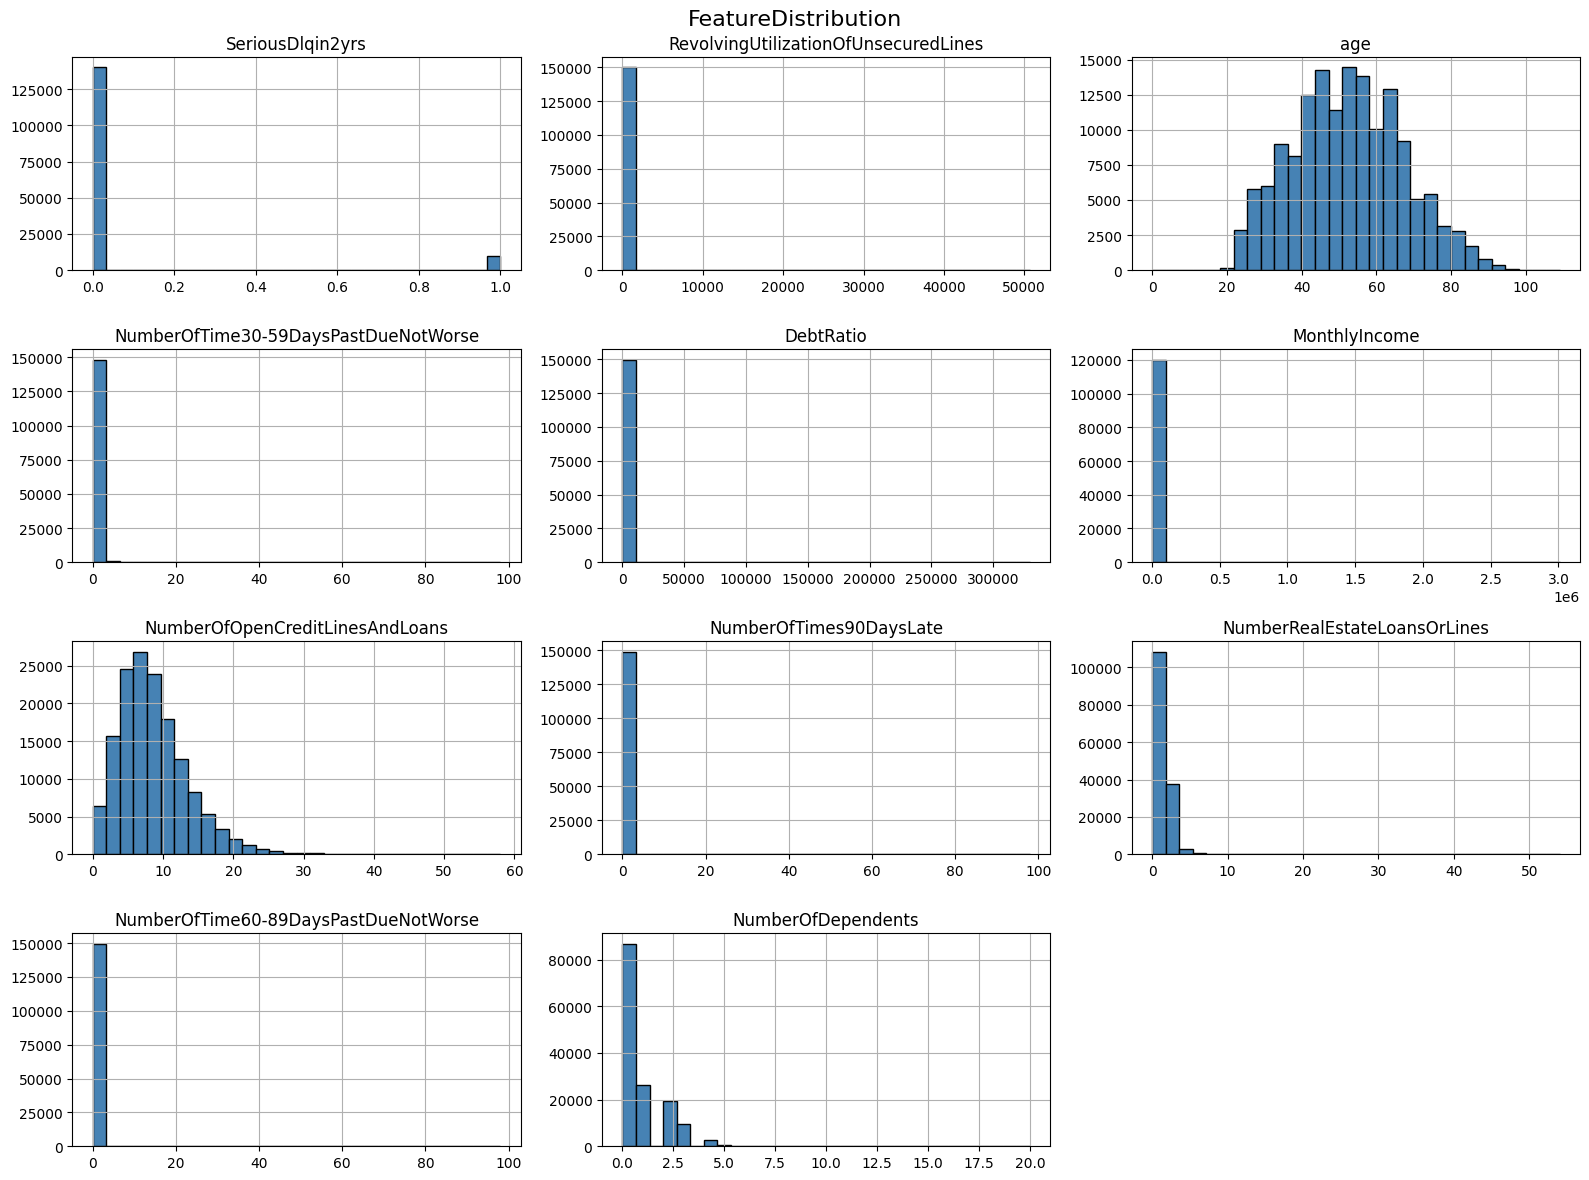

In [5]:
df.hist(figsize=(16,12),bins=30,color='steelblue',edgecolor='black')
plt.suptitle('FeatureDistribution',fontsize=16)
plt.tight_layout()
plt.show()

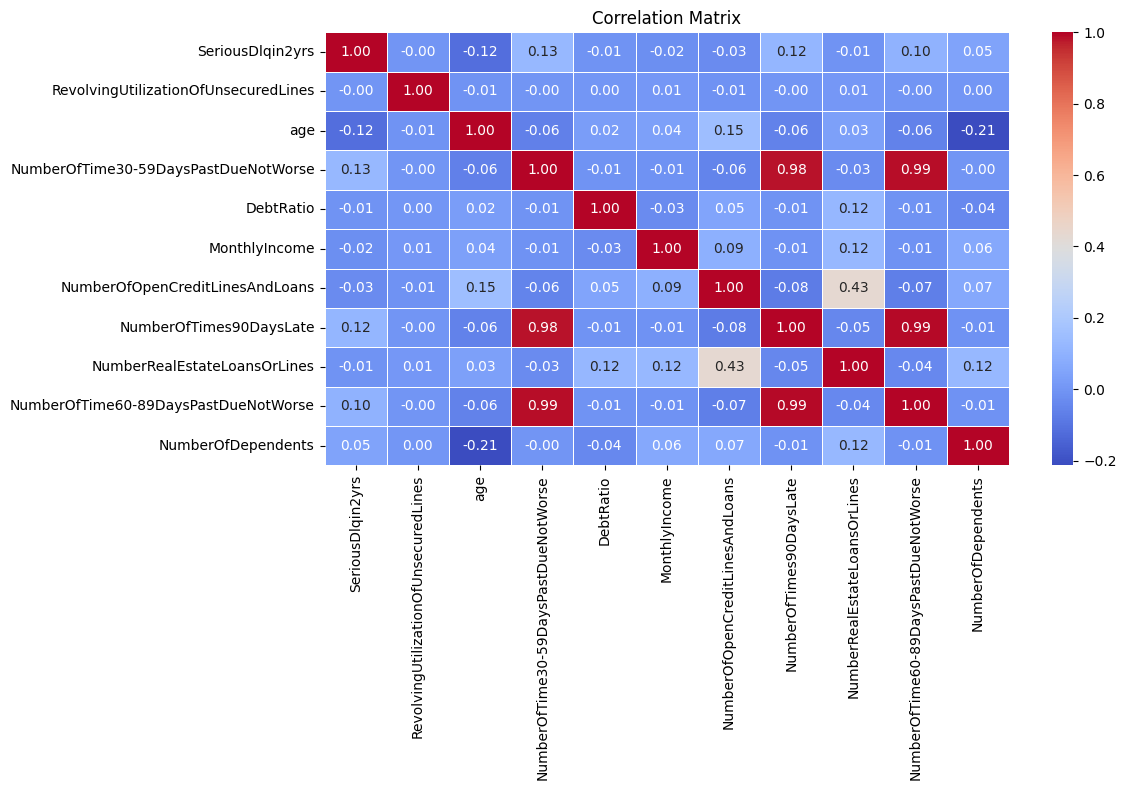

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

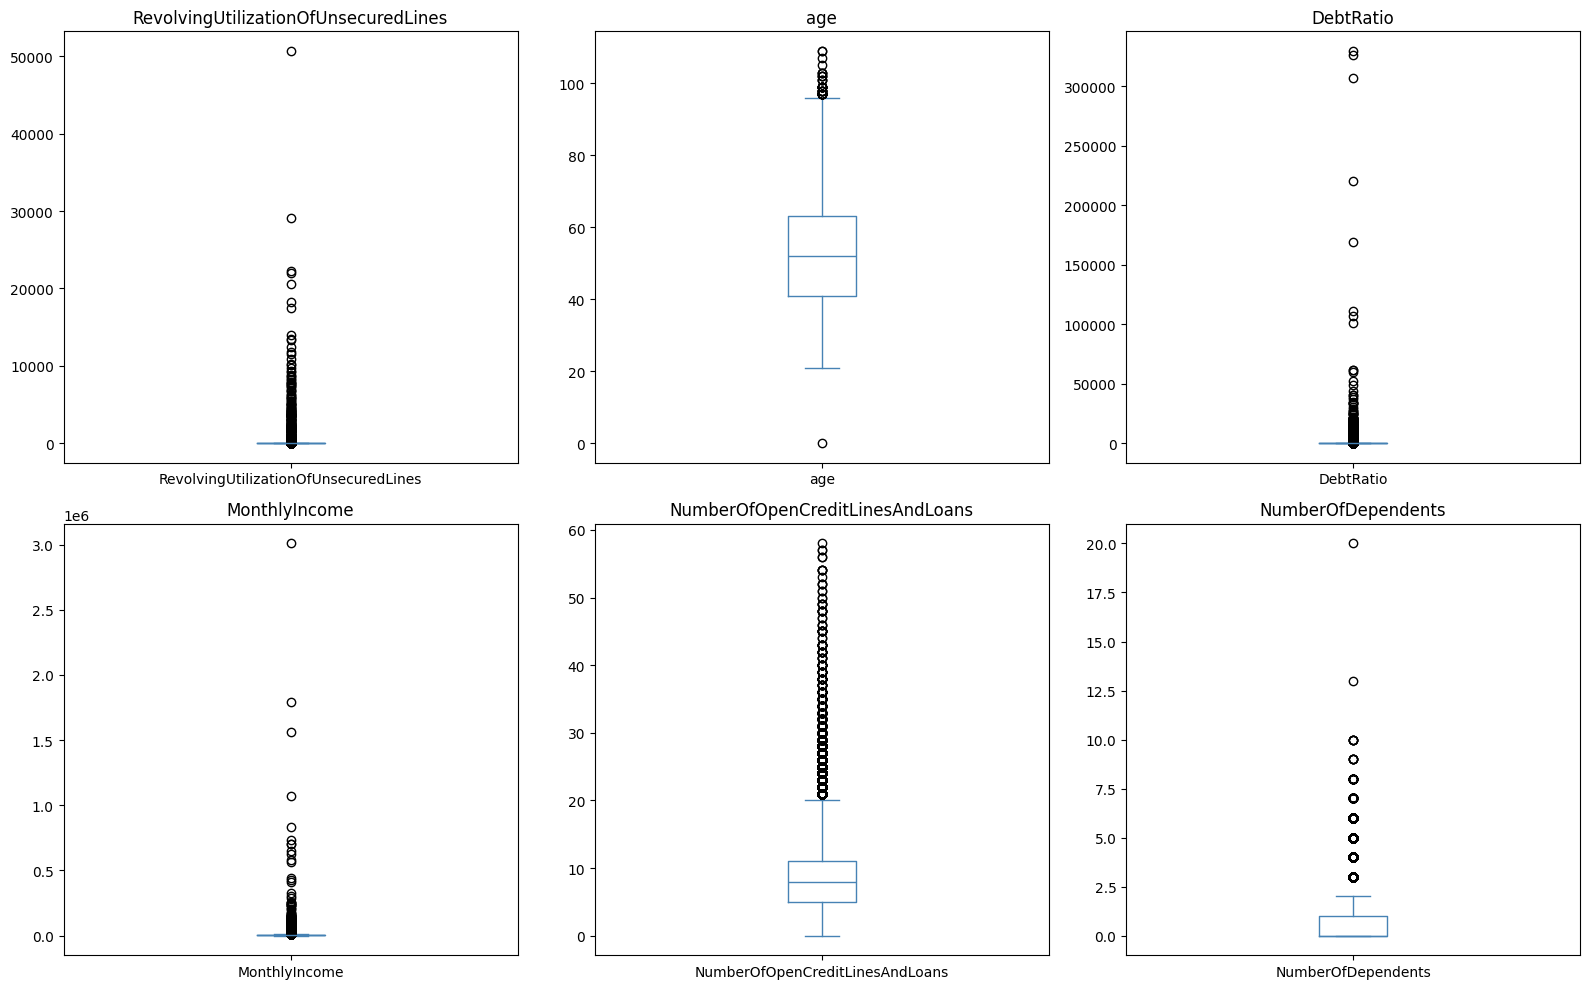

In [7]:
fig,axes=plt.subplots(2,3,figsize=(16,10))
cols=['RevolvingUtilizationOfUnsecuredLines', 'age', 
        'DebtRatio', 'MonthlyIncome', 
        'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents']

for ax,col in zip(axes.flatten(),cols):
    df[col].plot(kind='box',ax=ax,color='steelblue')
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split as tts
from sklearn.pipeline import  Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
import pickle
import os

In [11]:
df.columns = [
    'target', 'revolving_utilization', 'age',
    'late_30_59', 'debt_ratio', 'monthly_income',
    'open_credit_lines', 'late_90_days', 'real_estate_loans',
    'late_60_89', 'dependents'
]
print(df.columns.tolist())
df.head()

['target', 'revolving_utilization', 'age', 'late_30_59', 'debt_ratio', 'monthly_income', 'open_credit_lines', 'late_90_days', 'real_estate_loans', 'late_60_89', 'dependents']


,target,revolving_utilization,age,late_30_59,debt_ratio,monthly_income,open_credit_lines,late_90_days,real_estate_loans,late_60_89,dependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [12]:
print("Age = 0:", (df['age']==0).sum())
df=df[df['age']>0]

print("Utilization>1 : ",(df['revolving_utilization']>1).sum())
df=df[df['revolving_utilization']<=1]

print("DebtRatio>1: ",(df['debt_ratio']>1).sum())
df=df[df['debt_ratio']<=1]

print("Shape after cleaning : ",df.shape)

Age = 0: 1
Utilization>1 :  3321
DebtRatio>1:  34416
Shape after cleaning :  (112262, 11)


In [ ]:
median_income = df['monthly_income'].median()
median_dep = df['dependents'].median()

df['monthly_income'] = df['monthly_income'].fillna(median_income)
df['dependents'] = df['dependents'].fillna(median_dep)

print("Missing values remaining:")
print(df.isnull().sum())

Missing values remaining:
target                   0
revolving_utilization    0
age                      0
late_30_59               0
debt_ratio               0
monthly_income           0
open_credit_lines        0
late_90_days             0
real_estate_loans        0
late_60_89               0
dependents               0
dtype: int64


In [15]:
X=df.drop('target',axis=1)
y=df['target']

In [16]:
X_train,X_test,y_train,y_test=tts(
    X,y,test_size=0.2,random_state=42,stratify=y
)
print("Train size: ",X_train.shape)
print("Test size: ",X_test.shape)
print("\nTrain target audience")
print(y_train.value_counts(normalize=True)*100)

Train size:  (89809, 10)
Test size:  (22453, 10)

Train target audience
target
0    93.959403
1     6.040597
Name: proportion, dtype: float64


In [18]:
scaler=RobustScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

X_train_scaled=pd.DataFrame(X_train_scaled,columns=X.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X.columns)


In [21]:
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)   
X_train_scaled.to_csv('data/processed/X_train.csv', index=False)
X_test_scaled.to_csv('data/processed/X_test.csv',   index=False)
y_train.to_csv('data/processed/y_train.csv',         index=False)
y_test.to_csv('data/processed/y_test.csv',           index=False)

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ All files saved!")

✅ All files saved!


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay,RocCurveDisplay
import xgboost as xgb


In [23]:
X_train = pd.read_csv('data/processed/X_train.csv')
X_test  = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('data/processed/y_test.csv').squeeze()

print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("\nTarget balance:")
print(y_train.value_counts(normalize=True) * 100)

Train: (89809, 10)
Test : (22453, 10)

Target balance:
target
0    93.959403
1     6.040597
Name: proportion, dtype: float64


In [27]:
# Fix: access the actual series properly
y_train_series = y_train['target'] if 'target' in y_train.index else y_train

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

if neg == pos:
    neg = (y_train.values == 0).sum()
    pos = (y_train.values == 1).sum()

scale = neg / pos

print(f"Negative cases (0): {neg}")
print(f"Positive cases (1): {pos}")
print(f"scale_pos_weight  : {scale:.2f}")

Negative cases (0): 84384
Positive cases (1): 5425
scale_pos_weight  : 15.55


In [30]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
def evaluate_model(name,model,X_train,y_train,X_test,y_test):
    cv_scores=cross_val_score(model,X_train,y_train,cv=cv,scoring='roc_auc',n_jobs=-1)


    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    y_prob=model.predict_proba(X_test)[:,1]

    auc=roc_auc_score(y_test,y_prob)
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"CV AUC (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Test AUC           : {auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return model, auc, y_prob

In [31]:
lr=LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42)

lr_model,lr_auc,lr_prob=evaluate_model(
    "Logistic Regression",lr,X_train,y_train,X_test,y_test
)




Model: Logistic Regression
CV AUC (mean ± std): 0.7882 ± 0.0066
Test AUC           : 0.7900

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.73      0.84     21097
           1       0.15      0.71      0.24      1356

    accuracy                           0.73     22453
   macro avg       0.56      0.72      0.54     22453
weighted avg       0.93      0.73      0.80     22453



In [32]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model, rf_auc, rf_prob = evaluate_model(
    "Random Forest", rf, X_train, y_train, X_test, y_test
)


Model: Random Forest
CV AUC (mean ± std): 0.8108 ± 0.0038
Test AUC           : 0.8208

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     21097
           1       0.54      0.11      0.19      1356

    accuracy                           0.94     22453
   macro avg       0.74      0.55      0.58     22453
weighted avg       0.92      0.94      0.92     22453



In [33]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,    # ← handles imbalance
    objective='binary:logistic',
    eval_metric='auc',
    early_stopping_rounds=50,
    random_state=42
)

# XGBoost early stopping needs eval_set
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, y_prob)

print(f"\nXGBoost Test AUC: {xgb_auc:.4f}")
print(f"Best iteration  : {xgb_model.best_iteration}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

[0]	validation_0-auc:0.80861
[50]	validation_0-auc:0.85083
[100]	validation_0-auc:0.85145
[125]	validation_0-auc:0.85063

XGBoost Test AUC: 0.8518
Best iteration  : 75

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     21097
           1       0.19      0.77      0.30      1356

    accuracy                           0.78     22453
   macro avg       0.58      0.77      0.59     22453
weighted avg       0.93      0.78      0.84     22453



In [35]:
results=pd.DataFrame({
    'Model' : ['Logistic Regression','Random Forest Classifier' , 'XGBoost'],
    'Test AUC':[lr_auc,rf_auc,xgb_auc]

}).sort_values('Test AUC', ascending=False)

print(results)

                      Model  Test AUC
2                   XGBoost  0.851797
1  Random Forest Classifier  0.820772
0       Logistic Regression  0.790034


C:\Users\TEXON WARE\AppData\Local\Temp\ipykernel_21096\293909858.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results,x='Model',y='Test AUC',palette='viridis')


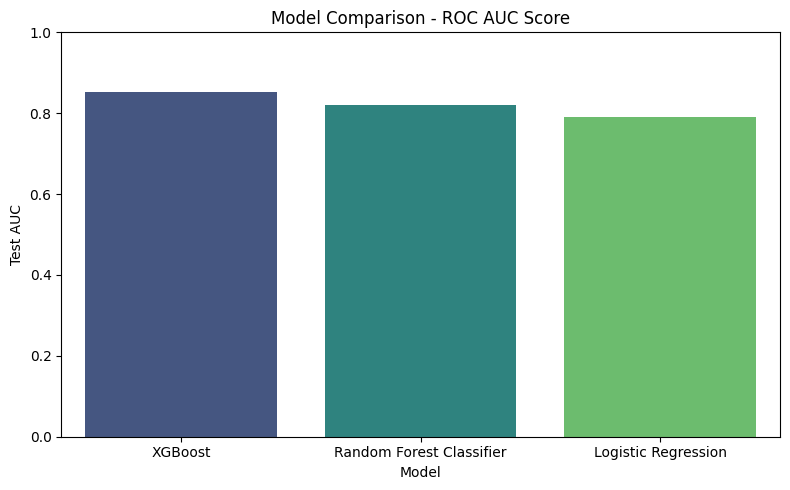

In [38]:
plt.figure(figsize=(8,5))
sns.barplot(data=results,x='Model',y='Test AUC',palette='viridis')
plt.title(
    'Model Comparison - ROC AUC Score')
plt.ylim(0,1.0)
plt.tight_layout()
plt.show()

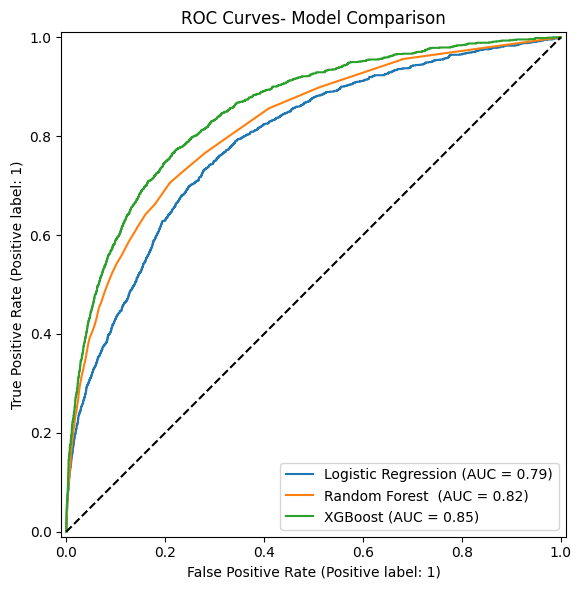

In [39]:
plt.figure(figsize=(8,6))
RocCurveDisplay.from_predictions(y_test,lr_prob,name="Logistic Regression" ,ax=plt.gca())
RocCurveDisplay.from_predictions(y_test,rf_prob,name="Random Forest " ,ax=plt.gca())
RocCurveDisplay.from_predictions(y_test,y_prob,name="XGBoost" ,ax=plt.gca())

plt.title('ROC Curves- Model Comparison')
plt.plot([0,1],[0,1],'k--',label='Random Guess')
plt.tight_layout()
plt.show()

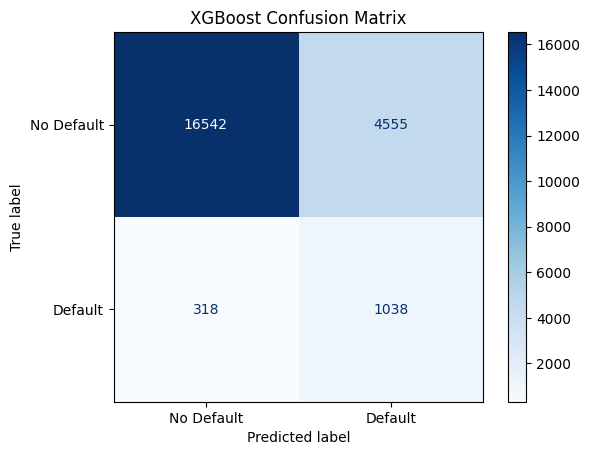

True Negatives  (correctly predicted no default): 16542
False Positives (wrongly flagged as default)    : 4555
False Negatives (missed actual defaults)        : 318
True Positives  (correctly caught defaults)     : 1038


In [40]:
cm = confusion_matrix(y_test, xgb_model.predict(X_test))
disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted no default): {tn}")
print(f"False Positives (wrongly flagged as default)    : {fp}")
print(f"False Negatives (missed actual defaults)        : {fn}")
print(f"True Positives  (correctly caught defaults)     : {tp}")


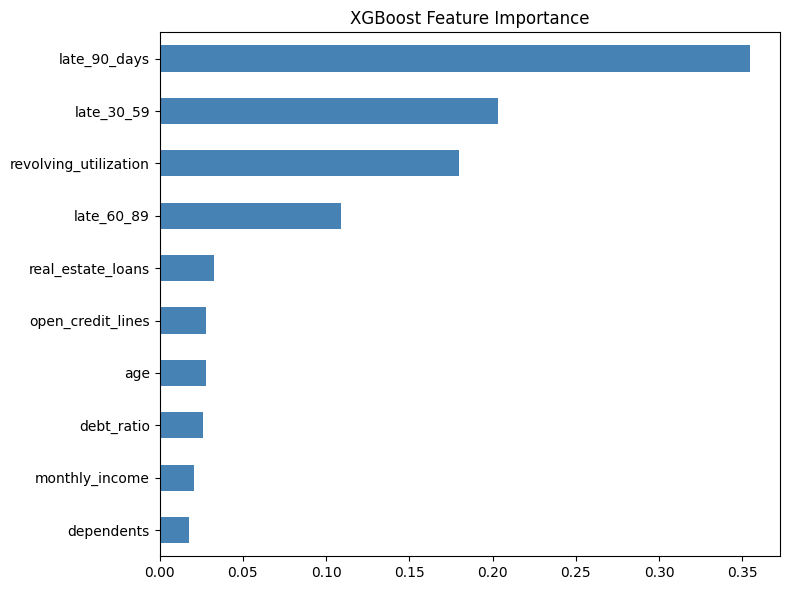

In [41]:
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

feat_imp.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

In [42]:
os.makedirs('models', exist_ok=True)

with open('models/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print("✅ XGBoost model saved to models/xgb_model.pkl")

✅ XGBoost model saved to models/xgb_model.pkl


In [43]:
import shap

In [44]:
# Load model and data
with open('models/xgb_model.pkl', 'rb') as f:
    model = pickle.load(f)

X_train = pd.read_csv('data/processed/X_train.csv')
X_test  = pd.read_csv('data/processed/X_test.csv')
y_test  = pd.read_csv('data/processed/y_test.csv').squeeze()

print("✅ Loaded model and data")
print("X_test shape:", X_test.shape)

✅ Loaded model and data
X_test shape: (22453, 10)


In [45]:
explainer=shap.TreeExplainer(model)
X_sample=X_test.sample(2000,random_state=42)
shap_values=explainer.shap_values(X_sample)
print(shap_values.shape)

(2000, 10)


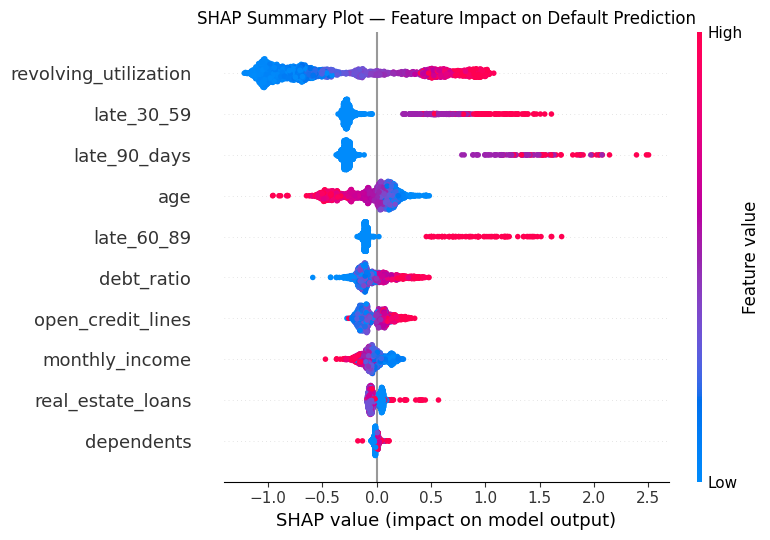

✅ Saved shap_summary.png


In [46]:
# Shows which features matter most AND their direction
plt.figure()
shap.summary_plot(
    shap_values, 
    X_sample,
    plot_type='dot',    # dot plot shows distribution
    show=False
)
plt.title('SHAP Summary Plot — Feature Impact on Default Prediction')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved shap_summary.png")


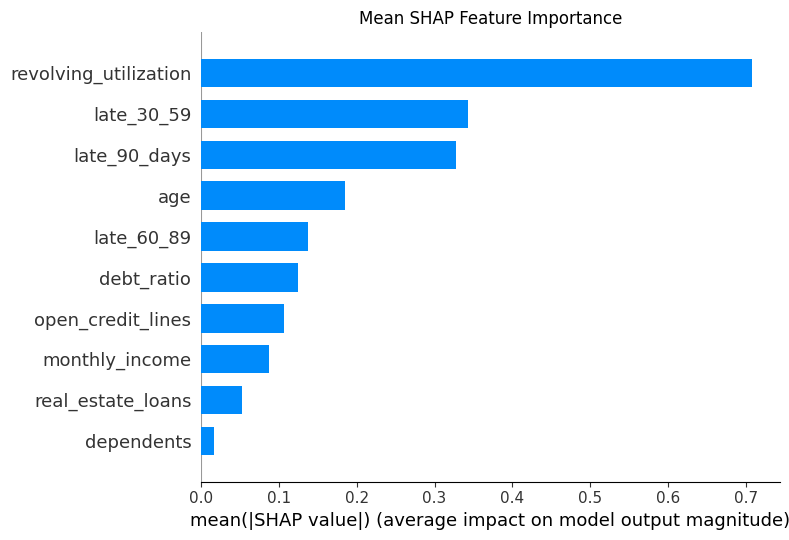

In [48]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar',    # simpler bar chart
    show=False
)
plt.title('Mean SHAP Feature Importance')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining person at index: 0
Default probability: 57.65%
Actual label: No Default


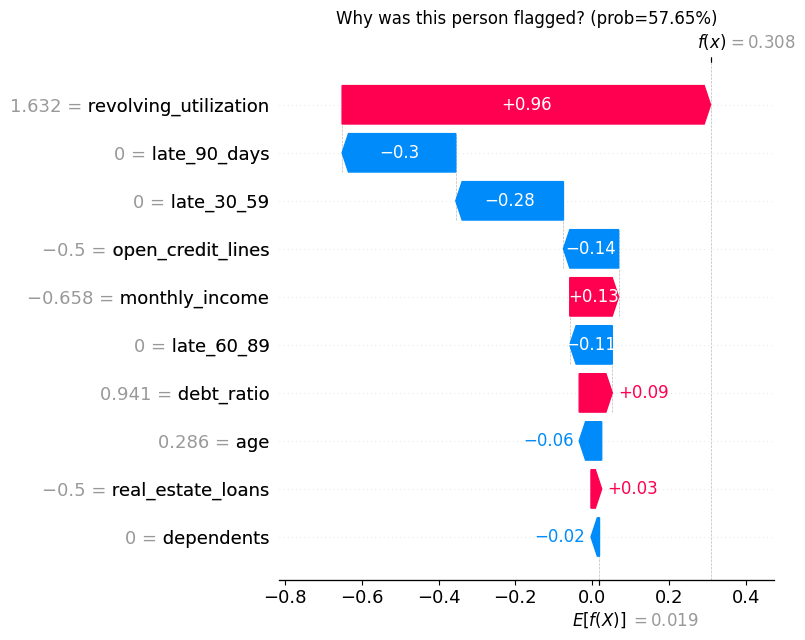

In [49]:
# Pick a person who was predicted as defaulter
y_prob = model.predict_proba(X_test)[:, 1]
default_indices = np.where(y_prob > 0.5)[0]
person_idx = default_indices[0]

print(f"Explaining person at index: {person_idx}")
print(f"Default probability: {y_prob[person_idx]:.2%}")
print(f"Actual label: {'Default' if y_test.iloc[person_idx]==1 else 'No Default'}")

# Calculate SHAP for this one person
shap_single = explainer(X_test.iloc[[person_idx]])

shap.waterfall_plot(shap_single[0], show=False)
plt.title(f'Why was this person flagged? (prob={y_prob[person_idx]:.2%})')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

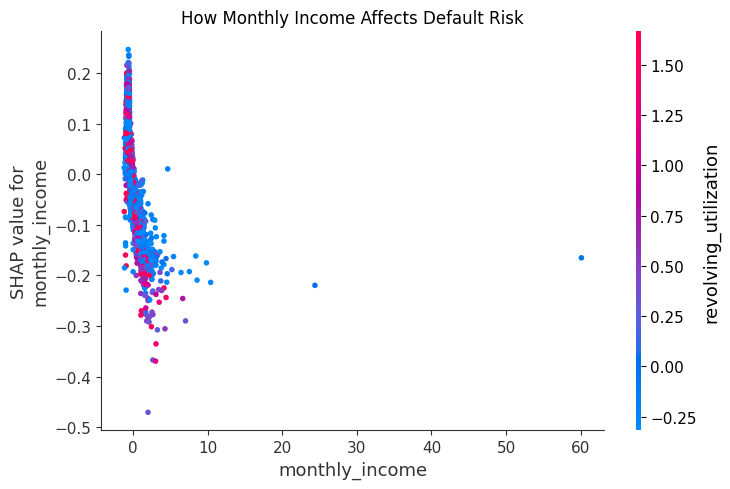

In [50]:
shap.dependence_plot(
    'monthly_income',
    shap_values,
    X_sample,
    show=False
)
plt.title('How Monthly Income Affects Default Risk')
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

In [54]:
most_risky_idx = y_prob.argmax()
most_safe_idx  = y_prob.argmin()

print("=" * 50)
print("MOST RISKY PERSON:")
print(f"Default probability: {y_prob[most_risky_idx]:.2%}")
print(X_test.iloc[most_risky_idx])

print("\n" + "=" * 50)
print("SAFEST PERSON:")
print(f"Default probability: {y_prob[most_safe_idx]:.2%}")
print(X_test.iloc[most_safe_idx])

MOST RISKY PERSON:
Default probability: 96.54%
revolving_utilization    1.666019
age                      0.095238
late_30_59               2.000000
debt_ratio               1.323690
monthly_income          -0.309037
open_credit_lines       -0.833333
late_90_days             8.000000
real_estate_loans        0.000000
late_60_89               1.000000
dependents               1.000000
Name: 14329, dtype: float64

SAFEST PERSON:
Default probability: 5.69%
revolving_utilization   -0.296049
age                      0.857143
late_30_59               0.000000
debt_ratio              -0.683224
monthly_income           5.334825
open_credit_lines       -0.500000
late_90_days             0.000000
real_estate_loans        0.000000
late_60_89               0.000000
dependents               0.000000
Name: 5950, dtype: float64


In [53]:
import os
os.makedirs('models', exist_ok=True)

with open('models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

